   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  


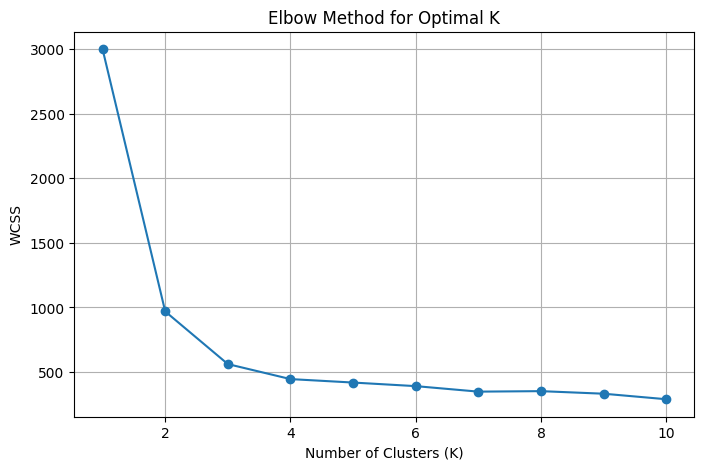


Cluster Centroids: 
         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  

Explained Variance Ratio by PCA: 
[0.83560354 0.05568764]

PCA Feature Loadings: 
           age  annual_spend  visits_per_month  basket_size  \
PCA1  0.411569       0.42154         -0.410399     0.412012   
PCA2 -0.259432      -0.03327          0.208318    -0.195402   

      days_since_last_visit  num_categories_purchased  
PCA1               0.378582                  0.414017  
PCA2               0.911194                 -0.140479  


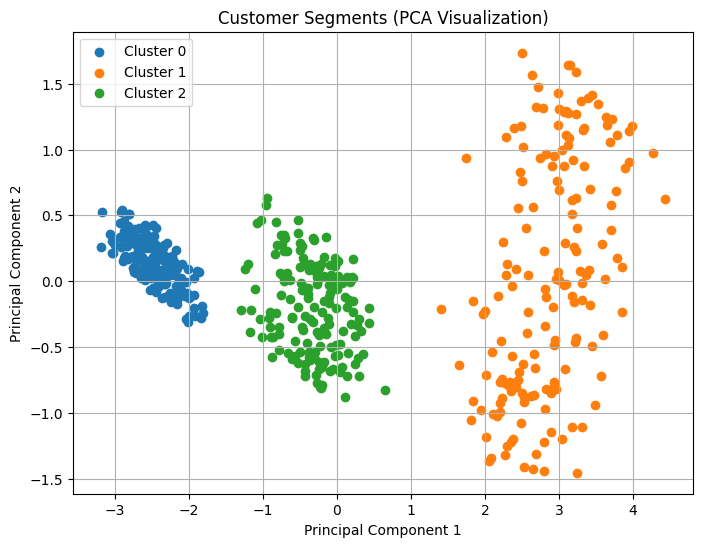

In [1]:
# -------------------------------
# Q2: UNSUPERVIESD LEARNING
# -------------------------------

# Import necessary libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------------
# STEP 1: DATA PREPARATION
# -------------------------------

# Load the dataset
df = pd.read_csv('q2_customers.csv')

# Display the first few rows of the dataset to understand its structure
print(df.head())

# Scaling the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Convert back to DATAFRAME for easier handling
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

# -------------------------------
# STEP 2: ELBOW METHOD (TO CHOOSE K )
# -------------------------------

wcss = []  # List to store the within-cluster sum of square for each K

# Trying K values from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)  # inertia_ gives the WCSS for the fited model

# Plotting the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

# -------------------------------
# STEP 3: K - MEANS CLUSTERING
# -------------------------------

# Choosing K (example: 3, adjust after observing the elbow plot)
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(scaled_df)

# Adding cluster labels to the original dataframe
df['Cluster'] = clusters

# Peinting Cluster Centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),  # Inverse transform to get original scale
    columns=df.columns[:-1]  # Exclude the 'Cluster' column
)

print("\nCluster Centroids: ")
print(centroids)

# -------------------------------
# STEP 4: PCA (Dimensionality Reduction)
# -------------------------------

pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
pca_data = pca.fit_transform(scaled_df)

# Create a DataFrame for PCA reults
pca_df = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2'])

# Add cluster labels to the PCA DataFrame
pca_df['Cluster'] = clusters

# Explained variance ratio
print("\nExplained Variance Ratio by PCA: ")
print(pca.explained_variance_ratio_)

# Feature Loadings
loadings = pd.DataFrame(
    pca.components_,
    columns = df.columns[:-1],  # Exclude the 'Cluster' column 
    index=['PCA1', 'PCA2']
)

print("\nPCA Feature Loadings: ")
print(loadings)

# -------------------------------
# STEP 5: VISUALIZATION OF CLUSTERS
# -------------------------------   

plt.figure(figsize=(8, 6))

# Scater plot of PCA results 
for cluster in range(optimal_k):
    cluster_data = pca_df[pca_df['Cluster'] == cluster]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=f'Cluster {cluster}')

plt.title("Customer Segments (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.show()





1. Why Scaling is essential before applying K-Means ?

K-Means clustering is based on distance (Euclidean distance). If features are on different scales (eg:- age vs annual_spend), largere values will dominate the distance calculation. Scaling ensures all features contribute equally, leading to more accurate clustering.


2. Justification and Explanation on my choice and Elbow Method.

The elbow method shows how WCSS decreases as K increases. The optimal K is chosen at the point where the decrease slows down significantly (the “elbow”). From the graph, K = 3 appears to be optimal because after this point, the improvement becomes marginal.

3. Interpretating Clusters in Business Terms: 

Cluster 0: Young customers with low spending but frequent visits.

Cluster 1: High spenders with large basket sizes and frequent visits.

Cluster 2: Infrequent customers with low engagement and long gaps between visits.

4. PCA Interpretations: 

PCA reduces the dataset into two components while preserving most variance: 

PC1 captures overall spending behaviour (annual spend, basket size).

PC2 captures customer engagement (visits per month, recency).